In [ ]:

import pandas as pd
import numpy as np


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
df = pd.read_csv(url)
df.head()


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:

print(df.shape)
print(df.isnull().sum())


df.drop('name', axis=1, inplace=True)


(195, 24)
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


In [ ]:

print(df.shape)
print(df.isnull().sum())


if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)

print(df.columns)


(195, 23)
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64
Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')


In [ ]:

X = df.drop('status', axis=1)
y = df['status']


In [ ]:
# --- CORRECTED CODE BLOCK TO REDUCE LEAKAGE ---

X = df.drop('status', axis=1)
y = df['status']

from sklearn.model_selection import train_test_split

# 1. SPLIT FIRST (on unscaled data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 2. FIT only on TRAINING data
X_train_scaled = scaler.fit_transform(X_train)

# 3. TRANSFORM test data using the training data's statistics
X_test_scaled = scaler.transform(X_test)

# Note: X_train_scaled and X_test_scaled are your new scaled datasets.
# --- END OF CORRECTED CODE BLOCK ---

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)


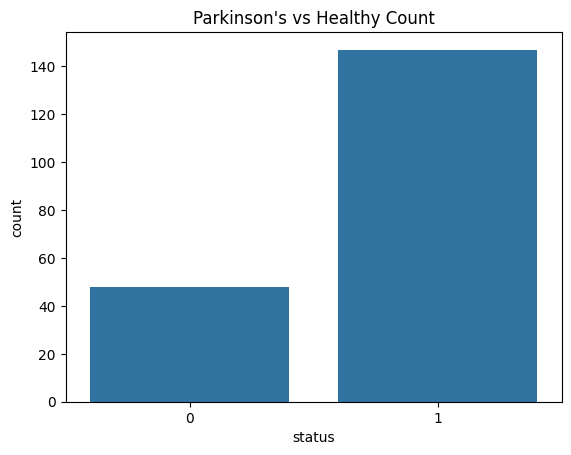

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Parkinson's vs Healthy Count")
plt.show()


In [ ]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_res))


Before SMOTE: [ 38 118]
After SMOTE : [118 118]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np # Often used for setting solver parameters


log_reg = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
log_reg.fit(X_train_res, y_train_res)


y_pred_lr = log_reg.predict(X_test)


print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

--- Logistic Regression ---
Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.95      0.72      0.82        29

    accuracy                           0.77        39
   macro avg       0.74      0.81      0.75        39
weighted avg       0.85      0.77      0.78        39

Confusion Matrix:
 [[ 9  1]
 [ 8 21]]


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train_res, y_train_res)


y_pred_svm = svm_clf.predict(X_test)

print("--- Support Vector Machine (SVM) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

--- Support Vector Machine (SVM) ---
Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.53      0.80      0.64        10
           1       0.92      0.76      0.83        29

    accuracy                           0.77        39
   macro avg       0.72      0.78      0.74        39
weighted avg       0.82      0.77      0.78        39

Confusion Matrix:
 [[ 8  2]
 [ 7 22]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
# n_neighbors (K) is a key parameter; 5 is a common starting point.
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_res, y_train_res)

# Make predictions
y_pred_knn = knn_clf.predict(X_test)

# Evaluate performance
print("--- K-Nearest Neighbors (KNN) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

--- K-Nearest Neighbors (KNN) ---
Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.90      0.95        29

    accuracy                           0.92        39
   macro avg       0.88      0.95      0.91        39
weighted avg       0.94      0.92      0.93        39

Confusion Matrix:
 [[10  0]
 [ 3 26]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
# max_depth is a common parameter to tune to prevent overfitting
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_clf.fit(X_train_res, y_train_res)

# Make predictions
y_pred_dt = dt_clf.predict(X_test)

# Evaluate performance
print("--- Decision Tree Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

--- Decision Tree Classifier ---
Accuracy: 0.8205128205128205
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.92      0.83      0.87        29

    accuracy                           0.82        39
   macro avg       0.77      0.81      0.78        39
weighted avg       0.84      0.82      0.83        39

Confusion Matrix:
 [[ 8  2]
 [ 5 24]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
# n_estimators is the number of trees in the forest
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train_res, y_train_res)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate performance
print("--- Random Forest Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

--- Random Forest Classifier ---
Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.90      0.87        39
weighted avg       0.91      0.90      0.90        39

Confusion Matrix:
 [[ 9  1]
 [ 3 26]]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
# n_estimators (number of boosting stages) and learning_rate are key parameters
gb_clf = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
gb_clf.fit(X_train_res, y_train_res)

# Make predictions
y_pred_gb = gb_clf.predict(X_test)

# Evaluate performance
print("--- Gradient Boosting Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

--- Gradient Boosting Classifier ---
Accuracy: 0.9743589743589743
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.97      0.98        29

    accuracy                           0.97        39
   macro avg       0.95      0.98      0.97        39
weighted avg       0.98      0.97      0.97        39

Confusion Matrix:
 [[10  0]
 [ 1 28]]


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC # Using linear for speed; rbf is an option too

# 1. Define the base models (Level 0)
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(kernel='linear', probability=True, random_state=42)), # Need probability=True for stacking
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

# 2. Define the final meta-model (Level 1)
# A simple Logistic Regression is a great default meta-estimator
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(solver='liblinear'),
    cv=5 # Use cross-validation to prevent data leakage
)

# 3. Train the stacked model
stack_clf.fit(X_train_res, y_train_res)

# 4. Make predictions
y_pred_stack = stack_clf.predict(X_test)

# 5. Evaluate
print("--- Stacking Classifier Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))

--- Stacking Classifier Performance ---
Accuracy: 0.9487179487179487
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39



In [ ]:
# Run these commands in your notebook/environment if you don't have them
!pip install xgboost lightgbm

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost requires the target variable to be an integer,
# which it already is in your case (0 and 1).
# We use XGBClassifier for classification tasks.

# Initialize and train the model
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='logloss', # Common evaluation metric for classification
    random_state=42
)
xgb_clf.fit(X_train_res, y_train_res)

# Make predictions
y_pred_xgb = xgb_clf.predict(X_test)

# Evaluate performance
print("--- XGBoost Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

--- XGBoost Classifier ---
Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39

Confusion Matrix:
 [[ 9  1]
 [ 2 27]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:09:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
lgb_clf = lgb.LGBMClassifier(
    objective='binary', # For binary classification
    n_estimators=100,
    metric='binary_logloss',
    random_state=42,
    verbose=-1 # Suppress warnings/info messages
)
lgb_clf.fit(X_train_res, y_train_res)

# Make predictions
y_pred_lgb = lgb_clf.predict(X_test)

# Evaluate performance
print("--- LightGBM Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))

--- LightGBM Classifier ---
Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39

Confusion Matrix:
 [[ 9  1]
 [ 2 27]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier # AdaBoost typically uses shallow Decision Trees as base estimators
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the base estimator (often a shallow tree)
base_estimator = DecisionTreeClassifier(max_depth=1)

# Initialize and train the model
ada_clf = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=1.0, # Default learning rate
    random_state=42
)
# Note: For newer scikit-learn versions, the parameter is 'estimator' not 'base_estimator'
ada_clf.fit(X_train_res, y_train_res)

# Make predictions
y_pred_ada = ada_clf.predict(X_test)

# Evaluate performance
print("--- AdaBoost Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))

--- AdaBoost Classifier ---
Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.90      0.87        39
weighted avg       0.91      0.90      0.90        39

Confusion Matrix:
 [[ 9  1]
 [ 3 26]]


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# --- Calculate Accuracy Scores ---
# These variables (y_test, y_pred_lr, etc.) must be defined by running
# the preceding training and prediction code blocks.

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)
acc_ada = accuracy_score(y_test, y_pred_ada)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
acc_lgb = accuracy_score(y_test, y_pred_lgb)
acc_stack = accuracy_score(y_test, y_pred_stack)

# --- Create Summary Table ---

results = {
    'Model': [
        'Logistic Regression',
        'SVM (Linear)',
        'K-Nearest Neighbors',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'AdaBoost',
        'XGBoost',
        'LightGBM',
        'Stacking Classifier'
    ],
    'Accuracy': [
        acc_lr,
        acc_svm,
        acc_knn,
        acc_dt,
        acc_rf,
        acc_gb,
        acc_ada,
        acc_xgb,
        acc_lgb,
        acc_stack
    ]
}

results_df = pd.DataFrame(results)

# Sort the results by Accuracy in descending order
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display the summary table
print("\n--- Model Accuracy Summary ---")
print(results_df)


--- Model Accuracy Summary ---
                 Model  Accuracy
0    Gradient Boosting  0.974359
1  Stacking Classifier  0.948718
2             LightGBM  0.923077
3  K-Nearest Neighbors  0.923077
4              XGBoost  0.923077
5        Random Forest  0.897436
6             AdaBoost  0.897436
7        Decision Tree  0.820513
8         SVM (Linear)  0.769231
9  Logistic Regression  0.769231
